# Notebook 02 — Fine-Tuning: Clasificador de Emoción

**Curso:** Minería de Textos | **Proyecto 3** | CUC

---

## Objetivo
Entrenar un clasificador de emoción sobre el corpus de canciones mediante fine-tuning de DistilBERT multilingüe.

Pasos:
1. Etiquetar el corpus con emociones (etiquetado automático por keywords)
2. Preparar el DatasetDict con split 70/15/15
3. Fine-tuning de `distilbert-base-multilingual-cased`
4. Evaluar: accuracy, F1 macro, matriz de confusión
5. Comparar con baseline zero-shot
6. Guardar el modelo

In [1]:
!pip install -q transformers datasets accelerate scikit-learn pymongo[srv] python-dotenv


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import sys
sys.path.append('../app')
sys.path.append('../src')

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from app.config import EMOCIONES, ID2EMOCION, FINETUNE_MODEL_DIR
from src.mongo_utils import mongo_utils
from src.finetuning_utils import finetuning_utils
from collections import Counter
from sklearn.metrics import accuracy_score, f1_score
from transformers import pipeline as hf_pipeline
import shutil

print('Librerias cargadas.')

C:\Users\pmari\OneDrive\Para Revisar\Documentos\Pablo\Cuc\2026\Mineria de Textos\chatbot-musical-inteligente\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Librerias cargadas.


In [3]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"--- Análisis de Hardware ---")
print(f"Dispositivo detectado: {device}")

if device == "cuda":
    print(f"Tarjeta Gráfica: {torch.cuda.get_device_name(0)}")
    print(f"Memoria VRAM disponible: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")
else:
    print("⚠️ Python no está usando la GPU. Revisa la instalación de CUDA.")

--- Análisis de Hardware ---
Dispositivo detectado: cuda
Tarjeta Gráfica: NVIDIA GeForce GTX 1650
Memoria VRAM disponible: 4.00 GB


## 1. Cargar corpus

In [4]:
db_conexion = mongo_utils()
if db_conexion.verificar_conexion():
   canciones=db_conexion.cargar_canciones()
   print(f'Canciones cargadas: {len(canciones)}')
else:
   canciones=[]
   print(f'Canciones no cargadas: {len(canciones)}')


2026-04-19 21:39:37 | INFO     | MongoDBManager | Conectando a MongoDB Atlas | DB: analisisMusical | Col: analisisMusical
2026-04-19 21:39:38 | INFO     | MongoDBManager | Conexión verificada correctamente.
2026-04-19 21:39:38 | INFO     | MongoDBManager | Cargando canciones | limite=None | solo_con_letra=True
2026-04-19 21:39:41 | INFO     | MongoDBManager | Canciones cargadas: 6940
Canciones cargadas: 6940


## 2. Etiquetado automático de emociones

In [5]:
finetuning = finetuning_utils()
dataset_etiquetado = finetuning.etiquetar_corpus_keywords(canciones)


2026-04-19 21:39:44 | INFO     | EmotionClassifier | Etiquetando corpus por keywords (6940 canciones)...
2026-04-19 21:39:44 | INFO     | EmotionClassifier | Etiquetadas: 3343 | Sin etiqueta: 3597
2026-04-19 21:39:44 | INFO     | EmotionClassifier | Distribución: {'amor': 2123, 'nostalgia': 351, 'tristeza': 299, 'rabia': 292, 'alegria': 278}


## 3. Preparar splits train / validation / test (70/15/15)

In [6]:
dataset_dict = finetuning.preparar_dataset_hf(dataset_etiquetado)
print(dataset_dict)

2026-04-19 21:39:46 | INFO     | EmotionClassifier | Preparando DatasetDict para HuggingFace...
2026-04-19 21:39:46 | INFO     | EmotionClassifier | Clases válidas (>=100): ['alegria', 'amor', 'nostalgia', 'rabia', 'tristeza']
2026-04-19 21:39:46 | INFO     | EmotionClassifier | Total muestras: 3343
2026-04-19 21:39:46 | INFO     | EmotionClassifier | Splits: train=2341 | val=501 | test=501
DatasetDict({
    train: Dataset({
        features: ['texto', 'emocion', 'titulo', 'artista', 'label'],
        num_rows: 2341
    })
    validation: Dataset({
        features: ['texto', 'emocion', 'titulo', 'artista', 'label'],
        num_rows: 501
    })
    test: Dataset({
        features: ['texto', 'emocion', 'titulo', 'artista', 'label'],
        num_rows: 501
    })
})


## 4. Baseline zero-shot (sin fine-tuning)

In [7]:
# Baseline: predecir siempre la clase más frecuente (sin ningún modelo externo)
muestra     = dataset_dict['test'].select(range(min(200, len(dataset_dict['test']))))
labels_real = [ID2EMOCION[l] for l in muestra['label']]

clase_mas_frecuente = Counter(labels_real).most_common(1)[0][0]
preds_zero          = [clase_mas_frecuente] * len(labels_real)

acc_zero = accuracy_score(labels_real, preds_zero)
f1_zero  = f1_score(labels_real, preds_zero, average='macro', zero_division=0)

print(f'BASELINE (mayoría de clase: "{clase_mas_frecuente}")')
print(f'Accuracy: {acc_zero:.4f} | F1 Macro: {f1_zero:.4f}')
print('Referencia para comparar con el modelo fine-tuneado.')

BASELINE (mayoría de clase: "amor")
Accuracy: 0.6800 | F1 Macro: 0.1619
Referencia para comparar con el modelo fine-tuneado.


## 5. Fine-Tuning con Class Weights

La matriz de confusión anterior mostró que **'amor'** dominaba las predicciones
por tener ~6x más muestras. Ahora usamos `WeightedTrainer` con
`CrossEntropyLoss(weight=class_weights)` — el modelo recibirá mayor penalización
por equivocarse en clases minoritarias como **rabia** y **nostalgia**.

Los pesos se calculan automáticamente con `compute_class_weight('balanced')`
de scikit-learn: peso = N_total / (N_clases × N_muestras_clase).

In [8]:
# Borrar modelo anterior para reentrenar desde cero con class weights
if Path(FINETUNE_MODEL_DIR).exists():
    shutil.rmtree(FINETUNE_MODEL_DIR)
    print(f'Modelo anterior eliminado: {FINETUNE_MODEL_DIR}')

num_labels = len(set(dataset_dict['train']['label']))
trainer, tokenizer, model = finetuning.entrenar(dataset_dict, num_labels=num_labels)

2026-04-19 21:39:54 | INFO     | EmotionClassifier | Iniciando fine-tuning de distilbert-base-multilingual-cased
2026-04-19 21:39:54 | INFO     | EmotionClassifier | Class weights calculados:
2026-04-19 21:39:54 | INFO     | EmotionClassifier |   alegria     : 2.3766
2026-04-19 21:39:54 | INFO     | EmotionClassifier |   tristeza    : 2.2085
2026-04-19 21:39:54 | INFO     | EmotionClassifier |   amor        : 0.3168
2026-04-19 21:39:54 | INFO     | EmotionClassifier |   rabia       : 2.2402
2026-04-19 21:39:54 | INFO     | EmotionClassifier |   nostalgia   : 1.9110


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 3679.28it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-multilingual-cased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Map: 100%|██████████| 501/501 [00:00<00:00, 2676.67 examples/s]

2026-04-19 21:40:00 | INFO     | EmotionClassifier | Dispositivo: GPU | Épocas: 8 | Batch: 16


2026-04-19 21:40:04 | INFO     | EmotionClassifier | Entrenando...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,1.586074,1.459357,0.564870,0.322509
2,1.150955,0.957875,0.750499,0.601883
3,0.591042,0.677042,0.816367,0.738014
4,0.376345,0.549461,0.856287,0.786571
5,0.198960,0.587071,0.880240,0.815726
6,0.176387,0.612806,0.898204,0.838388
7,0.145624,0.707431,0.884232,0.811328
8,0.088687,0.683236,0.892216,0.826837


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.23s/it]
There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].
Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.30s/it]

2026-04-20 00:06:37 | INFO     | EmotionClassifier | Modelo guardado en C:\Users\pmari\OneDrive\Para Revisar\Documentos\GitHub\chatbot-musical-inteligente\models\clasificador_emocion


## 6. Evaluación en test set

In [9]:
metricas = finetuning.evaluar(trainer, dataset_dict, tokenizer)

print(f'\nCOMPARACIÓN:')
print(f'  Zero-shot  →  Accuracy: {acc_zero:.4f} | F1: {f1_zero:.4f}')
print(f'  Fine-tuned →  Accuracy: {metricas["accuracy"]:.4f} | F1: {metricas["f1_macro"]:.4f}')
print(f'  Ganancia   →  +{metricas["accuracy"]-acc_zero:.4f} accuracy | +{metricas["f1_macro"]-f1_zero:.4f} F1')

2026-04-20 00:06:54 | INFO     | EmotionClassifier | Evaluando modelo en test set...


Map: 100%|██████████| 501/501 [00:00<00:00, 3847.39 examples/s]


2026-04-20 00:08:08 | INFO     | EmotionClassifier | Accuracy: 0.8623 | F1 Macro: 0.7702
2026-04-20 00:08:08 | INFO     | EmotionClassifier | Métricas guardadas en resultados/metricas.json

COMPARACIÓN:
  Zero-shot  →  Accuracy: 0.6800 | F1: 0.1619
  Fine-tuned →  Accuracy: 0.8623 | F1: 0.7702
  Ganancia   →  +0.1823 accuracy | +0.6083 F1


## 7. Matriz de confusión

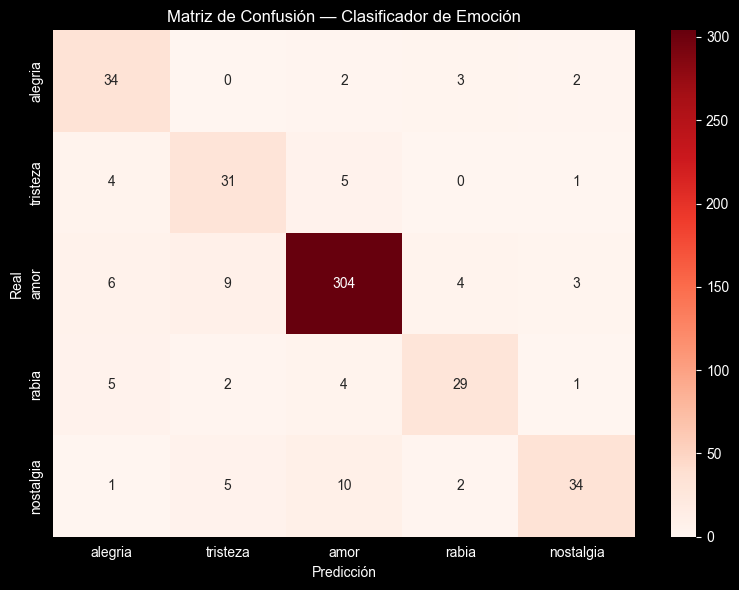

In [10]:
cm = np.array(metricas['confusion_matrix'])
clases = [ID2EMOCION[i] for i in range(len(cm))]

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=clases, yticklabels=clases)
plt.title('Matriz de Confusión — Clasificador de Emoción', color='white')
plt.xlabel('Predicción', color='white')
plt.ylabel('Real', color='white')
plt.tight_layout()
plt.show()

## 8. Prueba del clasificador fine-tuneado

In [11]:
frases_prueba = [
    'Me duele el corazón, no puedo dejar de llorar por ti',
    'Bailando hasta el amanecer, la vida es una fiesta',
    'Te amo con todo mi ser, eres mi razón de existir',
    'Te odio, me traicionaste, nunca te voy a perdonar',
    'Recuerdo aquellos tiempos cuando éramos felices juntos',
]

clf_ft = hf_pipeline('text-classification', model=FINETUNE_MODEL_DIR,
                     tokenizer=FINETUNE_MODEL_DIR, top_k=1, truncation=True)

for frase in frases_prueba:
    raw = clf_ft(frase[:256])
    while isinstance(raw, list):
        raw = raw[0]
    print(f'Emoción: {raw["label"]:12s} ({raw["score"]:.2%}) → "{frase[:60]}..."')

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 3252.71it/s]


Emoción: amor         (58.75%) → "Me duele el corazón, no puedo dejar de llorar por ti..."
Emoción: alegria      (97.59%) → "Bailando hasta el amanecer, la vida es una fiesta..."
Emoción: tristeza     (92.61%) → "Te amo con todo mi ser, eres mi razón de existir..."
Emoción: tristeza     (90.91%) → "Te odio, me traicionaste, nunca te voy a perdonar..."
Emoción: amor         (91.97%) → "Recuerdo aquellos tiempos cuando éramos felices juntos..."


## 9. Etiquetar TODO el corpus con el modelo fine-tuneado

Este es el paso que conecta el fine-tuning con el RAG.
El clasificador entrenado asigna una emocion a CADA cancion del corpus.
El resultado se guarda en cache y el Notebook 02 lo usa para construir el indice FAISS.

In [12]:
# Etiquetar todo el corpus con el clasificador fine-tuneado
# Esto puede tardar unos minutos dependiendo del tamano del corpus
corpus_etiquetado = finetuning.etiquetar_corpus_con_modelo(canciones, forzar=True)

print(f'\nCorpus listo para el RAG: {len(corpus_etiquetado)} canciones etiquetadas')
print('Ahora ejecuta el Notebook 03 para construir el indice FAISS.')

2026-04-20 00:09:26 | INFO     | EmotionClassifier | Cargando clasificador desde C:\Users\pmari\OneDrive\Para Revisar\Documentos\GitHub\chatbot-musical-inteligente\models\clasificador_emocion...


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 6317.82it/s]


2026-04-20 00:09:27 | INFO     | EmotionClassifier | Clasificando 6940 canciones en batches de 64...
2026-04-20 00:09:28 | INFO     | EmotionClassifier |   Procesadas: 64/6940


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


2026-04-20 00:09:42 | INFO     | EmotionClassifier |   Procesadas: 704/6940
2026-04-20 00:09:58 | INFO     | EmotionClassifier |   Procesadas: 1344/6940
2026-04-20 00:10:11 | INFO     | EmotionClassifier |   Procesadas: 1984/6940
2026-04-20 00:10:25 | INFO     | EmotionClassifier |   Procesadas: 2624/6940
2026-04-20 00:10:39 | INFO     | EmotionClassifier |   Procesadas: 3264/6940
2026-04-20 00:10:52 | INFO     | EmotionClassifier |   Procesadas: 3904/6940
2026-04-20 00:11:06 | INFO     | EmotionClassifier |   Procesadas: 4544/6940
2026-04-20 00:11:19 | INFO     | EmotionClassifier |   Procesadas: 5184/6940
2026-04-20 00:11:34 | INFO     | EmotionClassifier |   Procesadas: 5824/6940
2026-04-20 00:11:50 | INFO     | EmotionClassifier |   Procesadas: 6464/6940
2026-04-20 00:12:01 | INFO     | EmotionClassifier | Corpus etiquetado: 6940 canciones
2026-04-20 00:12:01 | INFO     | EmotionClassifier |   amor        :  2483 (35.8%)
2026-04-20 00:12:01 | INFO     | EmotionClassifier |   rabia 